In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Scripts.pam_generation import setup_ecolicore_pam
# from Modules.utils import calculate_r_squared_for_reaction
# from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations
    
ECOLI_PHENOTYPE_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes')
PARAMETER_RESULT_FILE = os.path.join('Results', 'pam_parametrizer_diagnostics_ecolicore_false_multiple_csources.xlsx')

Loading PAModelpy modules version 0.0.3.3


# 1. Load reference data (proteomics and fluxes)

In [2]:
# load proteome data (Schmidt et al. 2016)
proteome_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='ProteinMasses',
                            engine='openpyxl',
                            index_col=0)
proteome_df_metadata = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='GrowthRates',
                            engine='openpyxl',
                            index_col=0)
proteome_df_cog = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'proteome_data_extract_schmidt2016.xlsx'),
                            sheet_name='Gene2COG',
                            engine='openpyxl',
                            index_col=0)
proteome_df.head()


,Glucose,LB,Glycerol + AA,Acetate,Fumarate,Glucosamine,Glycerol,Pyruvate,Chemostat µ=0.5,Chemostat µ=0.35,...,Stationary phase 1 day,Stationary phase 3 days,Osmotic-stress glucose,42°C glucose,pH6 glucose,Xylose,Mannose,Galactose,Succinate,Fructose
Bnumber,,,,,,,,,,,,,,,,,,,,,
b3988,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,0.702820,1.230766,1.004203,...,0.446640,0.491074,0.578723,1.026062,0.859739,0.934963,0.875724,0.581381,0.711635,1.162894
b3987,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,0.928398,1.310899,1.096833,...,0.594492,0.556592,0.813304,1.230390,1.007687,1.109002,1.035491,0.704953,0.963569,1.317061
b0118,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,2.543362,2.440666,3.143073,...,0.144782,0.117351,0.436610,0.751106,0.721180,1.038963,2.562241,1.997324,3.032313,1.362394
b2557,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,0.635390,0.536179,0.405983,...,0.144920,0.172421,0.309267,0.442385,0.400793,0.403734,0.413947,0.368480,0.448950,0.564445
b3212,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,0.458132,0.629009,0.530940,...,0.062205,0.049618,0.225865,0.807285,0.737951,0.676351,0.563197,0.378829,0.420765,1.045406


In [3]:
# load exchange rates for different carbon sources by Gerosa et al. (2015) in Ecoli BW25113
flux_csources = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py.xls'),
                       sheet_name = 'Fluxes_Csources',
                            engine='openpyxl',
                            index_col=1)
flux_csources_df = flux_csources.drop(['Flux (publication)', 'Reversibility'], axis=1)
flux_csources_df.head()

,Acetate,Fructose,Galactose,Glucose,Glycerol,Gluconate,Pyruvate,Succinate,Glucose (flux ratio Glc)
Reaction identifier,,,,,,,,,
EX_ac_e_b,13.584,-3.32866,-1.968939e-08,-6.827019,-0.597000,-5.003982,-11.91391,-3.320974,-0.70717
EX_fru_e_b,0.000,8.32800,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
EX_gal_e_b,0.000,0.00000,1.969000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
EX_glc__D_e_b,0.000,0.00000,0.000000e+00,9.654000,0.000000,0.000000,0.00000,0.000000,1.00000
EX_glyc_e_b,0.000,0.00000,0.000000e+00,0.000000,4.944834,0.000000,0.00000,0.000000,0.00000


# 2. Setup the Ecoli core model with new parameters

In [4]:
#setup the core model
ecolicore_pam_wt = setup_ecolicore_pam() # not curation for reference
ecolicore_pam_curated = setup_ecolicore_pam(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls')) # curated for reference
ecolicore_pam_new = setup_ecolicore_pam()

Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06
Read LP format model from file /tmp/tmppuuhlpzd.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Setting up the proteome allocation model e_coli_core

Add total condition-dependent protein constraint
	Total protein concentration: 0.16995 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: 

Done with setting up the proteome allocation model e_coli_core

Read LP format model from file /tmp/tmpl28c9_i5.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Setting up the proteome allocation model e_coli_core

Add total condition-dependent protein constraint
	Total protein concentration: 0.16995 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: 

Done with setting up the proteome allocation model e_coli_core



/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:222: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f'Molar mass for {enz.id} is invalid: {molmass}')


Read LP format model from file /tmp/tmpey3btxk5.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Setting up the proteome allocation model e_coli_core

Add total condition-dependent protein constraint
	Total protein concentration: 0.16995 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: 

Done with setting up the proteome allocation model e_coli_core



In [6]:
# extract the optimized kcats and do the changes
mutated_kcats = pd.read_excel(PARAMETER_RESULT_FILE, sheet_name='Best_Individuals')
mutated_kcats.groupby('run_id')
for i, row in mutated_kcats.iterrows():
    kcat_dict = {row['rxn_id']:{row['direction']:row['kcat[s-1]']}}
    ecolicore_pam_new.change_kcat_value(enzyme_id=row['enzyme_id'], kcats = kcat_dict)

# 3. Check internal flux distribution

In [7]:
def remove_suffixes(strings):
    modified_strings = []
    for string in strings:
        if string.endswith('_f') or string.endswith('_b'):
            modified_strings.append(string[:-2])  # Remove last two characters
        else:
            modified_strings.append(string)  # Keep the string unchanged
    return modified_strings

In [8]:
def enzyme_concentration(enz):
    fwd_value = enz.enzyme_variable.forward_variable.primal
    rev_value = enz.enzyme_variable.reverse_variable.primal
    return fwd_value+rev_value

def run_simulations(pamodel, substrate_ids, substrate_rates, fluxes_to_save = None, proteins_to_save = None) -> list:
    
    if fluxes_to_save is not None:
        fluxes = pd.DataFrame(columns = ['substrate_id', 'substrate_rate']+fluxes_to_save)
    if proteins_to_save is not None:
        proteins = pd.DataFrame(columns = ['EC_nmbr', 'fraction', 'growth_rate', 'substrate_id', 'substrate_rate'])
    
    pamodel.change_reaction_bounds(rxn_id='EX_glc__D_e',
                                       lower_bound=0, upper_bound=1e6)
    
    for substrate_id, substrate_rate in zip(substrate_ids, substrate_rates):
        pamodel.change_reaction_bounds(rxn_id=substrate_id,
                                       lower_bound=substrate_rate, upper_bound=0)
        print('Running simulations with ', substrate, 'mmol of ', substrate_id,' /g_cdw/h of substrate going into the system')
        sol_pam =pamodel.optimize()
        if pamodel.solver.status == 'optimal' and pamodel.objective.value>0:
            print('optimal', substrate_id)
            if fluxes_to_save is not None:
                solution_flux = [substrate_id, substrate_rate]+ \
                    [sol_pam[rxn] if rxn in pamodel.reactions else np.NaN for rxn in fluxes_to_save]
                fluxes.loc[len(fluxes)] = solution_flux
            if proteins_to_save is not None:
                total_conc = 0
                for enzid in proteins_to_save:
                    enzyme = pamodel.enzymes.get_by_id(enzid)
                    conc = enzyme_concentration(enzyme)
                    total_conc += conc
                    proteins.loc[len(proteins)] = [enzid, conc, pamodel.objective.value, substrate_id, substrate_rate]
        
        pamodel.change_reaction_bounds(rxn_id=substrate_id,
                                       lower_bound=0, upper_bound=1e6)
                
    if proteins_to_save is not None: 
        return proteins
    if fluxes_to_save is not None:
        return fluxes

In [9]:
def calculate_error_for_reactions(validation_df: pd.DataFrame,
                                   flux_df: pd.DataFrame,
                                  rxns_to_validate: list) -> float:
    # calculate error for different exchange rates
    error = []
    for rxn, substrate_id in zip(rxns_to_validate, flux_df.substrate_id):
        # only select the rows which are filled with data
        validation_data = validation_df.dropna(axis=0, subset=rxn)
        validation_data = validation_data.loc[substrate_id]
        # if there are no reference data points, continue to the next reaction
        if len(validation_data) == 0:
            continue

        r_squared = calculate_r_squared_for_reaction(rxn, validation_df, substrate_id,
                                                           flux_df[flux_df.substrate_id == substrate_id])
        error += [r_squared]
    return error

def calculate_r_squared_for_reaction(reaction_id: str, validation_data: pd.DataFrame,
                                     substrate_uptake_id: str,
                                      fluxes: pd.DataFrame) -> float:
    substr_rxn = substrate_uptake_id
    # Take the absolute value of substrate uptake to avoid issues with reaction directionality
    validation_data[substr_rxn] = [round(abs(flux),4) for flux in validation_data[substr_rxn]]
    simulated_data = pd.DataFrame({substr_rxn: [round(abs(flux),4) for flux in fluxes['substrate_rate']],
                                   'simulation': fluxes[reaction_id]})
    ref_data_rxn = pd.merge(validation_data,simulated_data,on=substr_rxn, how='inner')
    # error: squared difference
    ref_data_rxn = ref_data_rxn.assign(error=lambda x: (x[reaction_id] - x['simulation']) ** 2)

    # calculate R^2:
    data_average = np.nanmean(validation_data[reaction_id])
    residual_ss = np.nansum(ref_data_rxn.error)
    total_ss = np.nansum([(data - data_average) ** 2 for data in ref_data_rxn[reaction_id]])
    # calculating r_squared is only feasible of the numerator and the denomenator are both nonzero
    if (residual_ss == 0) | (total_ss == 0):
        r_squared = 0
    else:
        r_squared = 1 - residual_ss / total_ss
    return r_squared

## 3.1 Parse dataframes to validate the flux distribution

In [10]:
# Get the data for growth on multiple carbon sources from Gerosa et al. (2015)
# Make sure all the fluxes of backward reactions are inverted to match the model directionality
fluxes_to_simulate = flux_csources_df.copy()
new_indices = []
for i, row in fluxes_to_simulate.iterrows():
    if isinstance(row.name, str):
        if row.name[-2:] == '_b':
            new_indices.append(row.name[:-2])
            fluxes_to_simulate.loc[row.name]= -row
        else: 
            new_indices.append(row.name)
    else:
        new_indices.append(row.name)
            
fluxes_to_simulate.index = new_indices
fluxes_to_simulate_parsed = fluxes_to_simulate[fluxes_to_simulate.index.notnull()]
fluxes_to_simulate_parsed = fluxes_to_simulate_parsed.rename(index = {'BIOMASS_Ec_iML1515_WT_75p37M':'BIOMASS_Ecoli_core_w_GAM'}).drop('Glucose (flux ratio Glc)', axis = 1)

In [11]:
# extract the validation data and substrate information for each carbon source
flux_mapper = {col: fluxes_to_simulate_parsed.index[i] for i,col in enumerate(fluxes_to_simulate_parsed.columns)}
fluxes_to_save = []
# Get the fluxes we want to save
for flux in fluxes_to_simulate_parsed.index:
    if isinstance(flux, str):
        fluxes_to_save += [f for f in flux.split(', ')]

#parse the fluxes such that we can run and validate simulations easily
validation_df = pd.DataFrame(columns = list(fluxes_to_simulate_parsed.index))
substrate_ids = []
substrate_uptake = []
for substrate, fluxes in fluxes_to_simulate_parsed.items():
    substrate_ids += [flux_mapper[substrate]]
    substrate_uptake += [fluxes.loc[flux_mapper[substrate]]]
    validation_df = pd.concat([validation_df,fluxes.to_frame().T], ignore_index =True)

validation_df.index = list(flux_mapper.values())
validation_df

,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,TKT2,PPC,PPCK,ICDHyr,SUCDi,FUM,"MDH, MDH2, MDH3","ME1, ME2",ICL,BIOMASS_Ecoli_core_w_GAM
EX_ac_e,-1.358400e+01,-0.000,-0.000,-0.000,-0.000000,-0.000000,-0.000,-0.000,1.358425e-07,0.00000,...,0.718249,1.774145,3.114281e+00,4.696417,8.404765,8.404765,10.671300,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.328660e+00,-8.328,-0.000,-0.000,-0.000000,-0.000000,-0.000,-0.000,8.327452e-08,0.00000,...,1.788933,3.545669,3.589203e-01,4.566119,3.877105,3.877105,2.227706,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,1.968939e-08,-0.000,-1.969,-0.000,-0.000000,-0.000000,-0.000,-0.000,1.968946e-08,0.00000,...,0.058569,0.377386,8.489495e-01,0.496177,1.260858,1.260858,2.285119,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.827019e+00,-0.000,-0.000,-9.654,-0.000000,-0.000000,-0.000,-0.000,9.653732e-08,0.00000,...,0.584644,2.453331,5.408740e-01,2.977971,2.138073,2.138073,2.138073,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,5.970003e-01,-0.000,-0.000,-0.000,-4.944834,-0.000000,-0.000,-0.000,1.013568e-07,0.00000,...,0.904380,1.376469,-1.003518e-07,2.464836,1.840459,1.840459,1.840459,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.003982e+00,-0.000,-0.000,-0.000,-0.000000,-7.283923,-0.000,-0.000,7.283677e-08,0.00000,...,0.170985,1.943350,-7.211081e-08,1.154034,0.182358,0.182358,0.182358,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,1.191391e+01,-0.000,-0.000,-0.000,-0.000000,-0.000000,-26.714,-0.000,0.000000e+00,1.15701,...,0.090131,2.489449,1.164803e+00,7.979320,7.518256,7.518256,7.427797,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.320974e+00,-0.000,-0.000,-0.000,-0.000000,-0.000000,-0.000,-15.902,1.139998e+00,0.00000,...,1.369847,2.016110,2.971789e+00,3.038949,18.370434,17.230436,4.950705,1.239618e+01,1.164515e-01,0.5100


## 3.2 Run simulations

In [12]:
# for each study, run simulations
fluxes_curated = run_simulations(ecolicore_pam_curated, substrate_ids = substrate_ids, 
                                 substrate_rates = substrate_uptake,
                                 fluxes_to_save = fluxes_to_save)
print('\n')
fluxes_wt = run_simulations(ecolicore_pam_wt,  substrate_ids = substrate_ids, 
                                 substrate_rates = substrate_uptake,
                                 fluxes_to_save = fluxes_to_save)
print('\n')
fluxes_new = run_simulations(ecolicore_pam_new,  substrate_ids = substrate_ids, 
                                 substrate_rates = substrate_uptake,
                                 fluxes_to_save = fluxes_to_save)

Running simulations with  Succinate mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
optimal EX_ac_e
Running simulations with  Succinate mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
optimal EX_fru_e
Running simulations with  Succinate mmol of  EX_gal_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system
optimal EX_glc__D_e


/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gal_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gal_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_glyc_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cann

Running simulations with  Succinate mmol of  EX_glyc_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_glcn_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
optimal EX_pyr_e
Running simulations with  Succinate mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
optimal EX_succ_e


Running simulations with  Succinate mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_fru_e  /g_cdw/h of substrate going into the system


/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


optimal EX_fru_e
Running simulations with  Succinate mmol of  EX_gal_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system


...

optimal EX_pyr_e
Running simulations with  Succinate mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
optimal EX_succ_e


Running simulations with  Succinate mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
optimal EX_ac_e
Running simulations with  Succinate mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
optimal EX_fru_e
Running simulations with  Succinate mmol of  EX_gal_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_glc__D_e  /g_cdw/h of substrate going into the system


/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gal_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gal_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')


optimal EX_glc__D_e
Running simulations with  Succinate mmol of  EX_glyc_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_glcn_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system


/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_glyc_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_glyc_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_glcn_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Ca

optimal EX_pyr_e
Running simulations with  Succinate mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
optimal EX_succ_e


In [14]:
fluxes_new

,substrate_id,substrate_rate,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ecoli_core_w_GAM
0,EX_ac_e,-13.584,-2.844630,0.000,NaN,0.000,NaN,NaN,0.000,0.000000,...,0.005388,2.768728,NaN,2.806378,NaN,NaN,0.0,2.731077,2.768728,0.004994
1,EX_fru_e,-8.328,2.365393,-8.328,NaN,0.000,NaN,NaN,0.000,0.000000,...,0.694675,4.157073,NaN,6.002156,NaN,NaN,0.0,2.311990,4.157073,0.643873
2,EX_glc__D_e,-9.654,6.937803,0.000,NaN,-9.654,NaN,NaN,0.000,0.000000,...,0.721184,1.915492,NaN,3.830984,NaN,NaN,0.0,0.000000,1.915492,0.668444
3,EX_pyr_e,-26.714,13.821369,0.000,NaN,0.000,NaN,NaN,-26.714,0.000000,...,0.564775,4.936634,NaN,8.883093,NaN,NaN,0.0,0.990175,4.936634,0.523473
4,EX_succ_e,-15.902,7.325789,0.000,NaN,0.000,NaN,NaN,0.000,-12.534451,...,0.369749,12.534451,NaN,2.583683,NaN,NaN,0.0,9.950768,0.000000,0.342709


In [15]:
fluxes_curated

,substrate_id,substrate_rate,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ecoli_core_w_GAM
0,EX_ac_e,-13.584,-13.584,0.000,NaN,0.000,NaN,NaN,0.000,0.000,...,0.920737,10.348419,NaN,11.953383,NaN,NaN,5.093253,2.959150,9.657367,0.212888
1,EX_fru_e,-8.328,0.000,-8.328,NaN,0.000,NaN,NaN,0.000,0.000,...,2.072839,4.102699,NaN,6.149350,NaN,NaN,0.000000,0.753774,2.800425,0.714214
2,EX_glc__D_e,-9.654,0.000,0.000,NaN,-9.654,NaN,NaN,0.000,0.000,...,1.315312,4.724027,NaN,7.100662,NaN,NaN,0.000000,1.926885,4.303520,0.829367
3,EX_pyr_e,-26.714,0.000,0.000,NaN,0.000,NaN,NaN,-26.714,0.000,...,0.860606,13.017643,NaN,20.604249,NaN,NaN,1.191956,4.239081,13.017643,0.797670
4,EX_succ_e,-15.902,0.000,0.000,NaN,0.000,NaN,NaN,0.000,-15.902,...,1.278175,22.261206,NaN,11.092774,NaN,NaN,6.761992,10.164889,5.758448,0.627877


In [23]:
fluxes_wt

,substrate_id,substrate_rate,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ecoli_core_w_GAM
0,EX_fru_e,-8.328,4.774378,-4.011359,NaN,0.000000,NaN,NaN,0.00000,0.000000,...,0.227908,0.000000,NaN,0.000000,NaN,NaN,0.0,0.000000,0.0,0.211241
1,EX_glc__D_e,-9.654,4.168950,0.000000,NaN,-3.426868,NaN,NaN,0.00000,0.000000,...,0.186183,0.000000,NaN,0.000000,NaN,NaN,0.0,0.000000,0.0,0.172567
2,EX_pyr_e,-26.714,11.541355,0.000000,NaN,0.000000,NaN,NaN,-14.04759,0.000000,...,0.177911,0.000000,NaN,0.000000,NaN,NaN,0.0,0.000000,0.0,0.164900
3,EX_succ_e,-15.902,2.940165,0.000000,NaN,0.000000,NaN,NaN,0.00000,-3.779666,...,0.059594,3.779666,NaN,0.416423,NaN,NaN,0.0,3.363243,0.0,0.055236


In [17]:
#calculate R^2 value between simulations and experiments
error_curated = calculate_error_for_reactions(validation_df,
                                                 fluxes_curated,
                                                 fluxes_to_save)
print('R^2 values for the model with published parameter set :', np.nanmean(error_curated))

error_wt = calculate_error_for_reactions(validation_df,
                                                 fluxes_wt,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with parameters from GotEnzymes: ', np.nanmean(error_wt))


error_new = calculate_error_for_reactions(validation_df,
                                                 fluxes_new,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with the optimized parameters: ', np.nanmean(error_new))



R^2 values for the model with published parameter set : -2.9445283053923412
R^2 values for the model with parameters from GotEnzymes:  -0.46684899255725587
R^2 values for the model with the optimized parameters:  -0.8448979591815565


## 3.2 Visualize the simulation results for the different models

In [18]:
# validation_df_1.index = validation_df.index.str.split(', ')
validation_df_1 = validation_df.T.reset_index()
validation_df_1['index'] = validation_df_1['index'].str.split(', ')
validation_df_1 = validation_df_1.explode('index').set_index('index').T
validation_df_1
# validation_df = validation_df.explode()

index,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ecoli_core_w_GAM
EX_ac_e,13.5840,0.000,-0.000,0.000,-0.000000,-0.000000,0.000,0.000,1.358425e-07,0.00000,...,4.696417,8.404765,8.404765,10.671300,10.671300,10.671300,1.871037e+00,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.3287,8.328,-0.000,0.000,-0.000000,-0.000000,0.000,0.000,8.327452e-08,0.00000,...,4.566119,3.877105,3.877105,2.227706,2.227706,2.227706,1.651610e+00,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,0.0000,0.000,-1.969,0.000,-0.000000,-0.000000,0.000,0.000,1.968946e-08,0.00000,...,0.496177,1.260858,1.260858,2.285119,2.285119,2.285119,5.237651e-04,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.8270,0.000,-0.000,9.654,-0.000000,-0.000000,0.000,0.000,9.653732e-08,0.00000,...,2.977971,2.138073,2.138073,2.138073,2.138073,2.138073,-9.557242e-08,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,0.5970,0.000,-0.000,0.000,-4.944834,-0.000000,0.000,0.000,1.013568e-07,0.00000,...,2.464836,1.840459,1.840459,1.840459,1.840459,1.840459,-1.003463e-07,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.0040,0.000,-0.000,0.000,-0.000000,-7.283923,0.000,0.000,7.283677e-08,0.00000,...,1.154034,0.182358,0.182358,0.182358,0.182358,0.182358,-7.210584e-08,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,11.9139,0.000,-0.000,0.000,-0.000000,-0.000000,26.714,0.000,0.000000e+00,1.15701,...,7.979320,7.518256,7.518256,7.427797,7.427797,7.427797,1.930607e-01,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.3210,0.000,-0.000,0.000,-0.000000,-0.000000,0.000,15.902,1.139998e+00,0.00000,...,3.038949,18.370434,17.230436,4.950705,4.950705,4.950705,1.239618e+01,1.239618e+01,1.164515e-01,0.5100


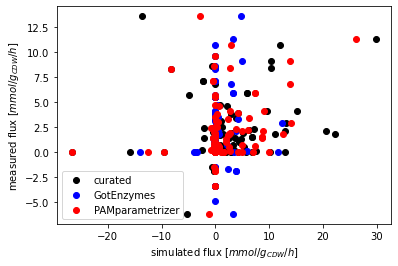

In [19]:
fig, ax = plt.subplots()

curated = []
wt = []
new = []
validation = []
for i in range(len(fluxes_curated)):
    curated += fluxes_curated.iloc[i].to_list()[2:]
    if i<len(fluxes_wt):
        wt += fluxes_wt.iloc[i].to_list()[2:]
    else:
        wt += [0]*len(fluxes_curated.iloc[i].to_list()[2:])
    if i<len(fluxes_new):
        new += fluxes_new.iloc[i].to_list()[2:]
    else:
        new += [0]*len(fluxes_curated.iloc[i].to_list()[2:])
    validation += validation_df_1.iloc[i].to_list()
      
plt.scatter(curated, validation, label = 'curated', color = 'black')
plt.scatter(wt, validation, label = 'GotEnzymes', color ='blue')
plt.scatter(new, validation, label = 'PAMparametrizer', color = 'red')

plt.xlabel('simulated flux [$mmol/g_{CDW}/h$]')
plt.ylabel('measured flux [$mmol/g_{CDW}/h$]')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


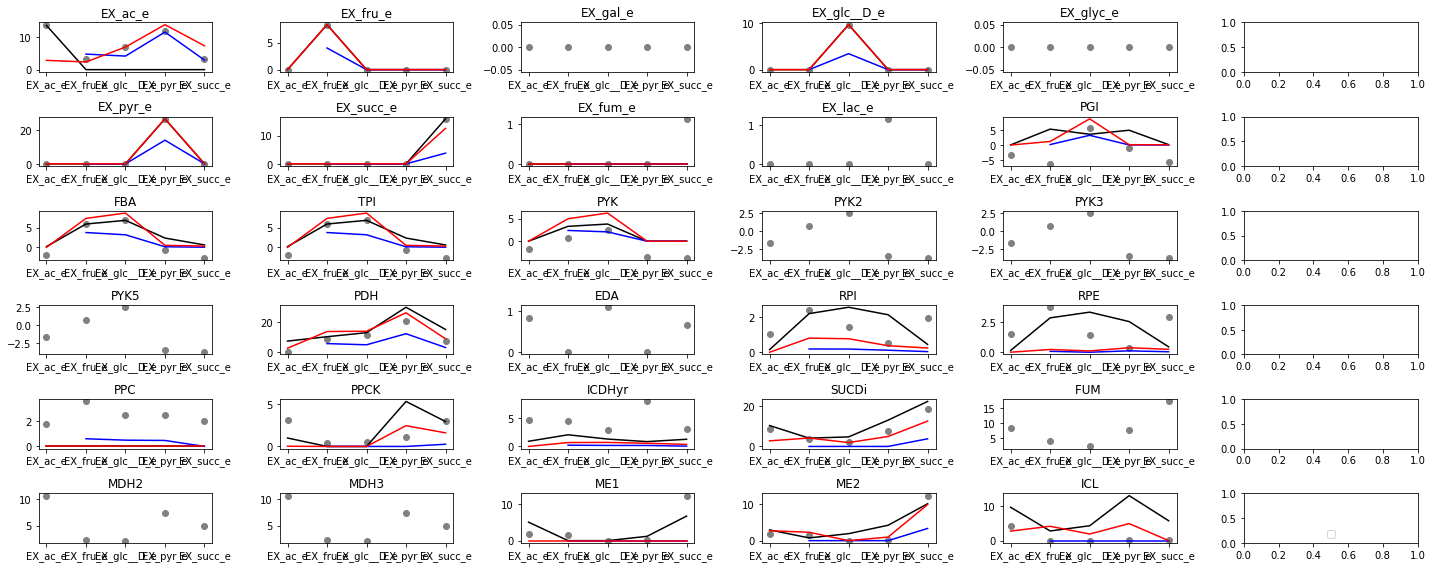

In [24]:
# visualize per flux
fig, axs = plt.subplots(ncols = 6, nrows = 6, figsize = [20,8])
substrate_ids_cur = fluxes_curated.substrate_id
substrate_ids = fluxes_new.substrate_id


#make the plot panels for each reaction
fig_reactions = []
for i in range(0,36,6):
    fig_reactions += [[rxn for rxn in fluxes_to_save[i:i+5]]]

# plot all reactions
for j in range(6):
    reactions_to_plot = fig_reactions[j]
    for i, rxn in enumerate(reactions_to_plot):
        validation = validation_df_1[rxn]
        axs[j,i].scatter(substrate_ids_cur, validation_df_1.loc[substrate_ids_cur, rxn], color = 'grey')
        axs[j,i].plot(substrate_ids_cur, fluxes_curated[rxn].abs(), label = 'curated', color = 'black')
        axs[j,i].plot(fluxes_wt['substrate_id'], fluxes_wt[rxn].abs(),label = 'GotEnzymes', color = 'blue')
        axs[j,i].plot(substrate_ids, fluxes_new[rxn].abs(), label = 'PAMparametrizer', color = 'red')
        axs[j,i].set_title(rxn)

    
plt.legend(loc = 'lower center')
plt.tight_layout()

plt.show()

# 4. Check protein distribution (glucose as C source)

## 4.1 Load the reference data from Schmidt et al (2011) and normalize the values

In [25]:
proteome_csources = proteome_df[['Acetate', 'Fructose', 'Succinate', 'Pyruvate', 'Glycerol']] #unit: fg/cell
proteome_csources

,Acetate,Fructose,Succinate,Pyruvate,Glycerol
Bnumber,,,,,
b3988,0.561253,1.162894,7.116349e-01,0.702820,0.732347
b3987,0.665163,1.317061,9.635688e-01,0.928398,0.936990
b0118,3.543745,1.362394,3.032313e+00,2.543362,1.674174
b2557,0.337313,0.564445,4.489504e-01,0.635390,0.485143
b3212,0.369212,1.045406,4.207655e-01,0.458132,0.597161
...,...,...,...,...,...
NaN,0.000097,NaN,2.050574e-04,0.000183,0.000170
NaN,0.000249,0.000001,1.026332e-06,0.000419,0.000252
NaN,0.000770,0.001285,2.757719e-04,0.000805,0.000709


In [26]:
# match the gene ids to the associated enzymes
gene_enzyme_mapper_df = pd.read_excel('Data/proteinAllocationModel_iML1515_EnzymaticData_230503.xls',
                                     sheet_name = 'ActiveEnzymes')[['rxnID', 'GPR', 'EC_nmbr']]
#make sure each gene gets its own row
gene_enzyme_mapper_df.GPR = gene_enzyme_mapper_df.GPR.str.split(' ')
gene_enzyme_mapper_df = gene_enzyme_mapper_df.explode('GPR').reset_index(drop =True)
gene_enzyme_mapper_df = gene_enzyme_mapper_df[(gene_enzyme_mapper_df.GPR != 'or') \
                                              & (gene_enzyme_mapper_df.GPR != 'and')]

to_delete = []
for i, row in gene_enzyme_mapper_df.iterrows():
    #remove brackets from the genes in and relationship (b.... and b....)
    if not isinstance(row.GPR, str): continue
    if '(' in row.GPR:
        gene_enzyme_mapper_df.loc[i, 'GPR'] = row.GPR[1:]
    if ')' in row.GPR:
        gene_enzyme_mapper_df.loc[i, 'GPR'] = row.GPR[:-1]
    #get the enzyme id from the model if EC number is not known and remove enzymes not in model
    if row.EC_nmbr not in ecolicore_pam_wt.enzymes:
        to_delete.append(i)
    if not isinstance(row.EC_nmbr, str) and row.rxnID in ecolicore_pam_wt.reactions:
        enzyme_id = ecolicore_pam_wt.get_enzymes_with_reaction_id(row.rxnID)[0]
        gene_enzyme_mapper_df.loc[i, 'EC_nmbr'] = enzyme_id
        
#only those entries which are in the model are useful
gene_enzyme_mapper_df = gene_enzyme_mapper_df.drop(index = to_delete)

gene_enzyme_mapper_df 

,rxnID,GPR,EC_nmbr
0,CYTDK2,b2066,4.2.1.17
1,CYTDK2,b2066,4.2.1.17
3,XPPT,b0238,2.2.1.6
4,XPPT,b0238,2.2.1.6
9,XPPT,b0238,2.2.1.6
...,...,...,...
9852,MOX,NaN,4.1.1.29
9853,MOX,NaN,4.1.1.15
9854,MOX,NaN,4.1.1.11
9872,HADPCOADH3,b1395,3.1.3.-


In [27]:
#filter the proteomics dataset to only have those genes which are in the model
gene_enzyme_mapper = gene_enzyme_mapper_df.set_index('EC_nmbr')
enz_in_model = [enz.id for enz in ecolicore_pam_new.enzymes]
enz_to_include = []
for i,row in gene_enzyme_mapper_df.iterrows():
    if row.EC_nmbr in enz_in_model: 
        enz_to_include += [row.EC_nmbr]

gene_enzyme_mapper = gene_enzyme_mapper.loc[enz_to_include].reset_index()

In [28]:
# match to the enzyme ids
proteome_enz = proteome_in_model.reset_index().merge(gene_enzyme_mapper, how = 'inner',
                                                      left_on = 'Bnumber', right_on = 'GPR')
proteome_enz = proteome_enz.drop_duplicates(['rxnID', 'Bnumber', 'EC_nmbr'])
proteome_enz

NameError: name 'proteome_in_model' is not defined

In [29]:
# normalize each experiment, resulting values are in protein fractions
proteome_normalized = proteome_enz.copy()
#make sure gene duplicates are ignored in the normalization
proteome_per_gene = proteome_enz.drop_duplicates(subset = 'Bnumber')
for col in proteome_in_model.columns:
    proteome_normalized[col] = proteome_enz[col].div(proteome_per_gene[col].sum())
proteome_normalized

NameError: name 'proteome_enz' is not defined

In [164]:
proteome_long = pd.melt(proteome_normalized, 
                        value_vars = ['Acetate', 'Fructose', 'Succinate', 'Pyruvate', 'Glycerol'], 
                            id_vars = ['Bnumber', 'rxnID', 'EC_nmbr'],
                           var_name = 'experiment', value_name = 'fraction')
proteome_long

,Bnumber,rxnID,EC_nmbr,experiment,fraction
0,b0118,ACONTb,2.2.1.6,Acetate,0.064490
1,b0118,MICITDr,2.2.1.6,Acetate,0.064490
2,b0118,ACONTa,2.2.1.6,Acetate,0.064490
3,b0118,ACONTb,2.5.1.18,Acetate,0.064490
4,b0118,ACONTa,2.5.1.18,Acetate,0.064490
...,...,...,...,...,...
510,b1478,ALCD2x,4.1.2.55,Glycerol,0.000042
511,b1478,ALCD2x,2.5.1.47,Glycerol,0.000042
512,b1812,ADCS,2.3.1.16,Glycerol,0.000042
513,b3114,OBTFL,2.3.1.-,Glycerol,0.000004


## 4.2 Run simulations and normalize the results

In [30]:
def enzyme_concentration(enz):
    fwd_value = enz.enzyme_variable.forward_variable.primal
    rev_value = enz.enzyme_variable.reverse_variable.primal
    return fwd_value+rev_value


def run_simulations_fixed_mu(pamodel, growth_rates, proteins_to_save) -> list:
    proteins = pd.DataFrame(columns = ['EC_nmbr', 'fraction', 'growth_rate', 'substrate_uptake'])
    #change_objective
    pamodel.objective = 'EX_glc__D_e'
    pamodel.objective.direction = 'min'
    
    for mu in growth_rates:
        pamodel.change_reaction_bounds(rxn_id='BIOMASS_Ecoli_core_w_GAM',
                                       lower_bound=mu, upper_bound=mu)
        print('Running simulations with to get a growth rate of', mu, 'h-1')
        sol_pam =pamodel.optimize()
        print(pamodel.solver.status)
        if pamodel.solver.status == 'optimal' and pamodel.objective.value<0:
            total_conc = 0
            for enzid in proteins_to_save:
                enzyme = pamodel.enzymes.get_by_id(enzid)
                conc = enzyme_concentration(enzyme)
                total_conc += conc
                proteins.loc[len(proteins)] = [enzid, conc, mu, pamodel.objective.value]

                
    pamodel.objective.direction = 'max'
    pamodel.objective = 'BIOMASS_Ecoli_core_w_GAM'
    return proteins

In [31]:
#setup the core model again to avoid conflicts in memory
ecolicore_pam_wt = setup_ecolicore_pam() # not curation for reference
ecolicore_pam_curated = setup_ecolicore_pam(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls')) # curated for reference
ecolicore_pam_new = setup_ecolicore_pam()

# extract the optimized kcats and do the changes
mutated_kcats = pd.read_excel(PARAMETER_RESULT_FILE, sheet_name='Best_Individuals')
mutated_kcats.groupby('run_id')
for i, row in mutated_kcats.iterrows():
    kcat_dict = {row['rxn_id']:{row['direction']:row['kcat[s-1]']}}
    ecolicore_pam_new.change_kcat_value(enzyme_id=row['enzyme_id'], kcats = kcat_dict)

Read LP format model from file /tmp/tmpujk37_wr.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Setting up the proteome allocation model e_coli_core

Add total condition-dependent protein constraint
	Total protein concentration: 0.16995 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: 

Done with setting up the proteome allocation model e_coli_core

Read LP format model from file /tmp/tmpi2j0_z63.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Setting up the proteome allocation model e_coli_core

Add total condition-dependent protein constraint
	Total protein concentration: 0.16995 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: 

Done with setting up the proteome allocation model e_coli_core



/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:222: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f'Molar mass for {enz.id} is invalid: {molmass}')


Read LP format model from file /tmp/tmph5bzdfmh.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Setting up the proteome allocation model e_coli_core

Add total condition-dependent protein constraint
	Total protein concentration: 0.16995 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: 

Done with setting up the proteome allocation model e_coli_core



In [32]:
# run the ecolicore model and save the enzyme concentrations
substrate_ids = ['EX_ac_e', 'EX_fru_e', 'EX_succ_e', 'EX_pyr_e', 'EX_gly_e']
substrate_rates = [-14, -10, -13, -27, -5]
proteins_to_save = [enz.id for enz in ecolicore_pam_curated.enzymes]
proteins_curated = run_simulations(ecolicore_pam_curated, substrate_ids,
                                   substrate_rates,
                                   proteins_to_save = proteins_to_save)
print('\n')
proteins_wt = run_simulations(ecolicore_pam_wt, substrate_ids,
                                   substrate_rates,
                              proteins_to_save = [enz.id for enz in ecolicore_pam_wt.enzymes])
print('\n')
proteins_new = run_simulations(ecolicore_pam_new, substrate_ids,
                                   substrate_rates,
                               proteins_to_save = [enz.id for enz in ecolicore_pam_new.enzymes])

Running simulations with  Succinate mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
optimal EX_ac_e
Running simulations with  Succinate mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
optimal EX_fru_e
Running simulations with  Succinate mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
optimal EX_succ_e
Running simulations with  Succinate mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
optimal EX_pyr_e


/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gly_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gly_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with  Succinate mmol of  EX_gly_e  /g_cdw/h of substrate going into the system


Running simulations with  Succinate mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
Running simulations with  Succinate mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
optimal EX_fru_e
Running simulations with  Succinate mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
optimal EX_succ_e
Running simulations with  Succinate mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
optimal EX_pyr_e


/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gly_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gly_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')


Running simulations with  Succinate mmol of  EX_gly_e  /g_cdw/h of substrate going into the system


Running simulations with  Succinate mmol of  EX_ac_e  /g_cdw/h of substrate going into the system
optimal EX_ac_e
Running simulations with  Succinate mmol of  EX_fru_e  /g_cdw/h of substrate going into the system
optimal EX_fru_e
Running simulations with  Succinate mmol of  EX_succ_e  /g_cdw/h of substrate going into the system
optimal EX_succ_e
Running simulations with  Succinate mmol of  EX_pyr_e  /g_cdw/h of substrate going into the system
optimal EX_pyr_e
Running simulations with  Succinate mmol of  EX_gly_e  /g_cdw/h of substrate going into the system


/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gly_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')
/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/samiralvdb/.local/lib/python3.10/site-packages/PAModelpy/PAModel.py:1078: UserWarning: Reaction EX_gly_e does not exist in the model. Cannot change the upper and lowerbound.
  warnings.warn(f'Reaction {rxn_id} does not exist in the model. Cannot change the upper and lowerbound.')


In [36]:
proteins_curated

,EC_nmbr,fraction,growth_rate,substrate_id,substrate_rate
0,2.3.3.16,59.288476,0.220590,EX_ac_e,-14
1,4.1.1.49,7.535841,0.220590,EX_ac_e,-14
2,1.1.1.38,10.751686,0.220590,EX_ac_e,-14
3,3.1.3.11,3.158037,0.220590,EX_ac_e,-14
4,2.7.1.40,0.000000,0.220590,EX_ac_e,-14
...,...,...,...,...,...
123,2.7.1.11,0.000000,0.805427,EX_pyr_e,-27
124,6.3.1.2,1.144154,0.805427,EX_pyr_e,-27
125,1.3.5.1,32.802673,0.805427,EX_pyr_e,-27
126,1.6.5.11,18.674317,0.805427,EX_pyr_e,-27


In [ ]:
proteome_long

In [37]:
# normalize the enzyme concentrations
def parse_protein_df(df):
    substrate2method = {-14:'Acetate' , -10:'Fructose', -13:'Succinate',
                       -27: 'Pyruvate', -5:'Glycerol'}
    df['method'] = df.apply(lambda x: substrate2method[x['substrate_rate']], axis =1)
    # Calculate sum of fraction grouped by substrate_uptake
    sum_by_substrate = df.groupby('substrate_rate')['fraction'].transform('sum')
    # Divide fraction values by the sum
    df['fraction'] = df['fraction'] / sum_by_substrate
    return df
    

#pivot to long format (one row per enzyme) different df with metadata for substrate and mu
proteins_curated_long = parse_protein_df(proteins_curated)

proteins_wt_long = parse_protein_df(proteins_wt)
proteins_new_long = parse_protein_df(proteins_new)
proteome_simulated = pd.merge(proteins_curated_long[['method', 'EC_nmbr', 'fraction']], 
                               proteins_wt_long[['method', 'EC_nmbr', 'fraction']], 
                              on = ['method', 'EC_nmbr'], how = 'outer', copy = False,
                             suffixes=('_curated', '_wt'))
proteome_simulated = pd.merge(proteome_simulated, 
                              proteins_new_long[['method', 'EC_nmbr', 'fraction']], 
                              on = ['method', 'EC_nmbr'], how = 'outer', copy = False,
                             suffixes = ('','_new'))
total_proteome_df = pd.merge(proteome_simulated, proteome_long,
                            left_on = ['method', 'EC_nmbr'], right_on = ['experiment', 'EC_nmbr'],
                            how = 'left', suffixes = ('_new', '_exp'))
total_proteome_df

NameError: name 'proteome_long' is not defined

,Bnumber,Acetate,Fructose,Succinate,Pyruvate,Glycerol,EC_nmbr,rxnID,GPR


## 4.3 Calculate the R^2 value for the predicted protein concentrations

## 4.4 Compare individual protein concentrations

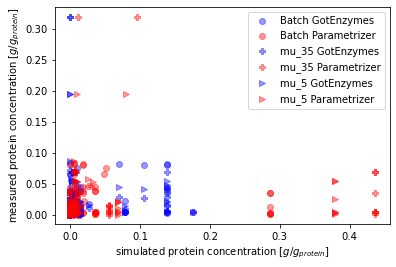

In [25]:
fig, ax = plt.subplots()
grouped = total_proteome_df.groupby('method')
markers = {'mu_5': '>', 'mu_35':'P', 'Batch':'o'}

for group, df in grouped:
    ax.scatter(df['fraction_wt'], df['fraction_exp'],
            c='blue', marker = markers[group], alpha = 0.4, label = group + ' GotEnzymes')
    ax.scatter(df['fraction_new'], df['fraction_exp'],
            c= 'red', marker = markers[group], alpha = 0.4, label = group + ' Parametrizer')

plt.xlabel('simulated protein concentration [$g/g_{protein}$]')
plt.ylabel('measured protein concentration [$g/g_{protein}$]')
plt.legend()
plt.show()

## 4.5 Compare fractional protein distribution over the different metabolic pathways (COG)

In [26]:
# map to COGs
total_proteome_df_cog = total_proteome_df.merge(proteome_df_cog[['COG Name']], left_on = 'Bnumber', right_index=True)

In [27]:
cog_data_groups = total_proteome_df_cog.groupby(['experiment', 'COG Name'])
cog_data_summed = cog_data_groups[['fraction_wt', 'fraction_new', 'fraction_exp']].sum()
cog_data_summed

fraction_wt  \
experiment COG Name                                                          
Batch      Amino acid transport and metabolism                    0.153402   
           Carbohydrate transport and metabolism                  1.041340   
           Energy production and conversion                       0.430285   
           General function prediction only                       0.176403   
           Nucleotide transport and metabolism                    0.000000   
           Posttranslational modification, protein turnove...     0.000000   
           Secondary metabolites biosynthesis, transport a...     0.000000   
mu_35      Amino acid transport and metabolism                    0.153402   
           Carbohydrate transport and metabolism                  1.041340   
           Energy production and conversion                       0.430285   
           General function prediction only                       0.176403   
           Nucleotide transport and metabolism                    0.000000   
           Posttranslational modification, protein turnove...     0.000000   
           Secondary metabolites biosynthesis, transport a...     0.000000   
mu_5       Amino acid transport and metabolism                    0.153402   
           Carbohydrate transport and metabolism                  1.041340   
           Energy production and conversion                       0.430285   
           General function prediction only                       0.176403   
           Nucleotide transport and metabolism                    0.000000   
           Posttranslational modification, protein turnove...     0.000000   
           Secondary metabolites biosynthesis, transport a...     0.000000   

                                                               fraction_new  \
experiment COG Name                                                           
Batch      Amino acid transport and metabolism                     0.079352   
           Carbohydrate transport and metabolism                   0.298249   
           Energy production and conversion                        2.398397   
           General function prediction only                        0.036328   
           Nucleotide transport and metabolism                     0.000000   
           Posttranslational modification, protein turnove...      0.000000   
           Secondary metabolites biosynthesis, transport a...      0.000000   
mu_35      Amino acid transport and metabolism                     0.100178   
           Carbohydrate transport and metabolism                   0.351130   
           Energy production and conversion                        3.513408   
           General function prediction only                        0.000797   
           Nucleotide transport and metabolism                     0.000000   
           Posttranslational modification, protein turnove...      0.000000   
           Secondary metabolites biosynthesis, transport a...      0.000000   
mu_5       Amino acid transport and metabolism                     0.115088   
           Carbohydrate transport and metabolism                   0.429671   
           Energy production and conversion                        3.140674   
           General function prediction only                        0.010389   
           Nucleotide transport and metabolism                     0.000000   
           Posttranslational modification, protein turnove...      0.000000   
           Secondary metabolites biosynthesis, transport a...      0.000000   

                                                               fraction_exp  
experiment COG Name                                                          
Batch      Amino acid transport and metabolism                     0.240472  
           Carbohydrate transport and metabolism                   0.710373  
           Energy production and conversion                        0.849193  
           General function prediction only                 

In [28]:
#treemap
import squarify

# Plotting the treemap
plt.figure(figsize=(8, 6))
squarify.plot(cog_data_summed.fraction_wt, label=None, color='blue', alpha=0.7)

# Add labels
for i, size in enumerate(sizes):
    plt.text(squarify.SIZES[i][0], squarify.SIZES[i][1], f'Size: {size}', ha='center', va='center', fontsize=8)

# Customize plot appearance
plt.axis('off')  # Turn off axis
plt.title('Treemap Example')
plt.show()

ModuleNotFoundError: No module named 'squarify'